In [1]:
import torch

# 1. Check PyTorch and CUDA status
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: CUDA is not available. Please check your Kaggle GPU settings.")

# 2. Install dependencies and Detectron2
!pip install pyyaml==5.1
!pip install 'git+https://github.com/facebookresearch/detectron2.git'

PyTorch Version: 2.10.0+cu128
CUDA Available: True
CUDA Version: 12.8
GPU Device: Tesla T4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 6.5 MB/s eta 0:00:00a 0:00:01
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-44ww28ls
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-44ww28ls
  Resolved https://github.com/facebookresearch/detectron2.git to commit 8a9d885b3d4dcf1bef015f0593b872ed8d32

In [3]:
import os
from detectron2.data.datasets import register_coco_instances
from detectron2.data import DatasetCatalog, MetadataCatalog

# --- IMPORTANT: Replace this path with your copied Kaggle input path ---
DATASET_ROOT = "/kaggle/input/datasets/mbmck26/roboflow-maskrcnn-dataset-2"

# Loop through the folders provided by Roboflow
for split in ["train", "valid", "test"]:
    dataset_name = f"my_dataset_{split}"

    # Roboflow usually names the annotation file _annotations.coco.json
    json_file = os.path.join(DATASET_ROOT, split, "_annotations.coco.json")
    image_root = os.path.join(DATASET_ROOT, split)

    # This prevents errors if you accidentally run this cell multiple times
    if dataset_name in DatasetCatalog.list():
        DatasetCatalog.remove(dataset_name)
        MetadataCatalog.remove(dataset_name)

    # Register the dataset
    register_coco_instances(dataset_name, {}, json_file, image_root)
    print(f"Registered: {dataset_name}")

# Let's verify by checking how many images are in the training set
try:
    dataset_dicts = DatasetCatalog.get("my_dataset_train")
    print(f"Success! Found {len(dataset_dicts)} images in the training set.")
except Exception as e:
    print(f"Error loading dataset: {e}")


Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.



Registered: my_dataset_train
Registered: my_dataset_valid
Registered: my_dataset_test
Success! Found 2142 images in the training set.


Starting Faster R-CNN training with RESNET-101 backbone for 5 classes...
[04/02 10:26:40 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): F

model_final_f6e8b1.pkl: 243MB [00:05, 46.4MB/s]                              
Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (6, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (6,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (20, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (20,) in the model! You might want to double check if this is expected.
Some model parameters or buffers are not found in the checkpoint:
roi_heads.bo

[04/02 10:26:46 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0402 10:26:48.958000 55 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[04/02 10:26:57 d2.utils.events]:  eta: 2:18:38  iter: 19  total_loss: 2.768  loss_cls: 1.706  loss_box_reg: 0.8779  loss_rpn_cls: 0.1716  loss_rpn_loc: 0.02644    time: 0.4099  last_time: 0.4153  data_time: 0.0119  last_data_time: 0.0039   lr: 4.9953e-06  max_mem: 2389M


2026-04-02 10:27:00.488746: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775125620.689996      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775125620.744511      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775125621.212065      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775125621.212094      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775125621.212096      55 computation_placer.cc:177] computation placer alr

[04/02 10:27:28 d2.utils.events]:  eta: 2:20:48  iter: 39  total_loss: 2.731  loss_cls: 1.628  loss_box_reg: 0.9353  loss_rpn_cls: 0.1484  loss_rpn_loc: 0.03415    time: 0.4303  last_time: 0.4934  data_time: 0.0056  last_data_time: 0.0050   lr: 9.9902e-06  max_mem: 2389M
[04/02 10:27:36 d2.utils.events]:  eta: 2:20:39  iter: 59  total_loss: 2.575  loss_cls: 1.426  loss_box_reg: 0.8489  loss_rpn_cls: 0.155  loss_rpn_loc: 0.03521    time: 0.4283  last_time: 0.4203  data_time: 0.0048  last_data_time: 0.0045   lr: 1.4985e-05  max_mem: 2389M
[04/02 10:27:45 d2.utils.events]:  eta: 2:21:54  iter: 79  total_loss: 2.258  loss_cls: 1.214  loss_box_reg: 0.9034  loss_rpn_cls: 0.1663  loss_rpn_loc: 0.03192    time: 0.4367  last_time: 0.4221  data_time: 0.0047  last_data_time: 0.0053   lr: 1.998e-05  max_mem: 2389M
[04/02 10:27:54 d2.utils.events]:  eta: 2:21:52  iter: 99  total_loss: 1.96  loss_cls: 1.008  loss_box_reg: 0.78  loss_rpn_cls: 0.1369  loss_rpn_loc: 0.02488    time: 0.4360  last_time: 

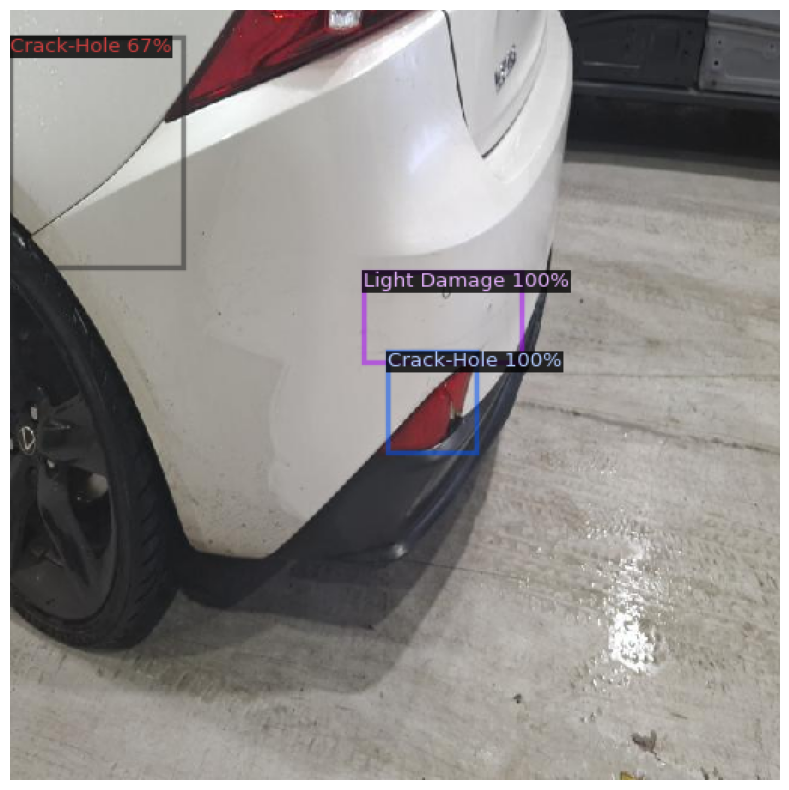

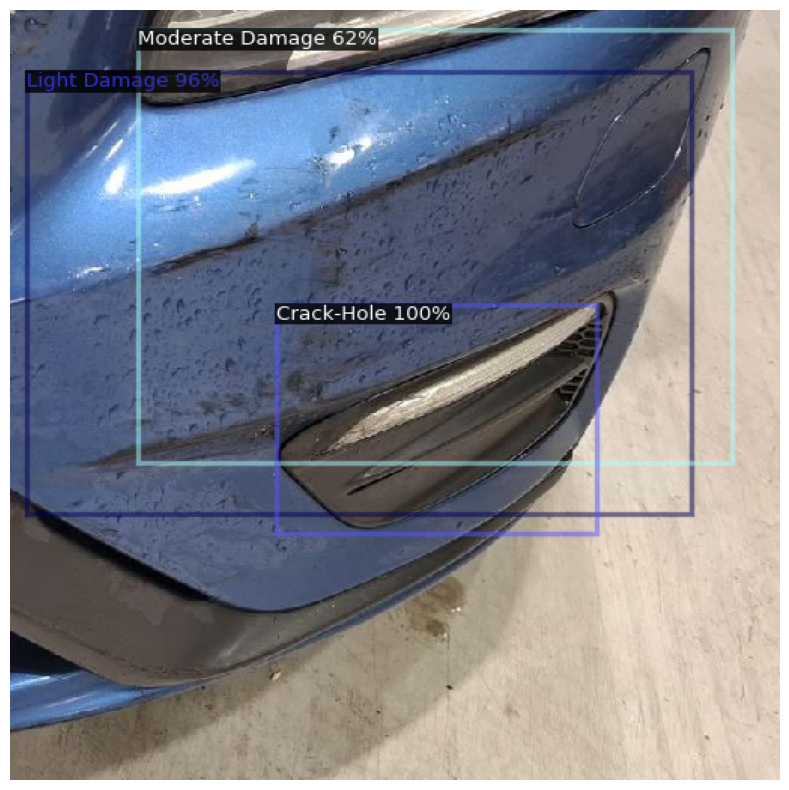

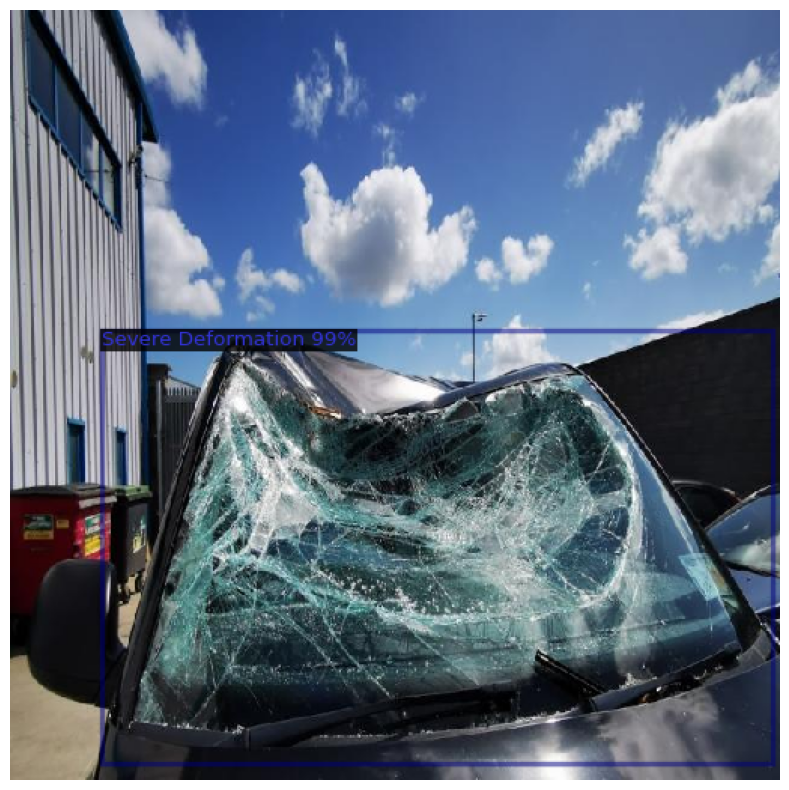

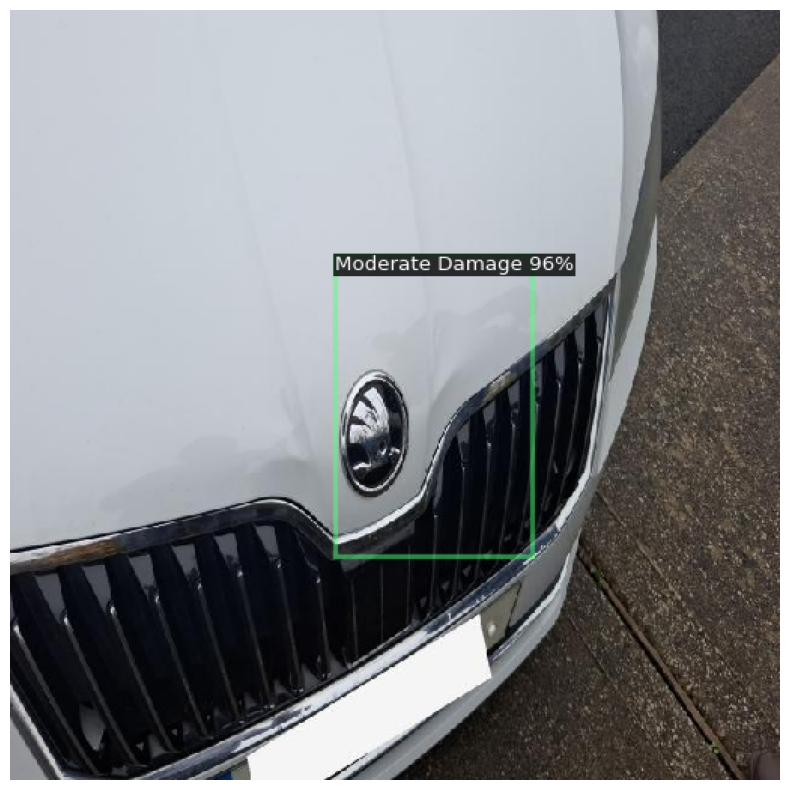

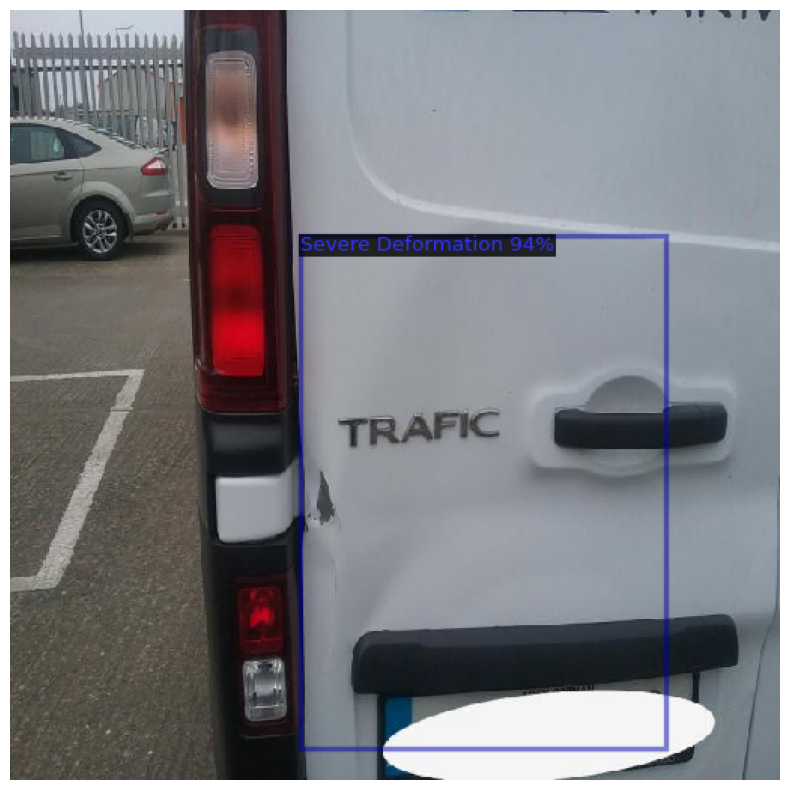

In [4]:
import os
import cv2
import random
import matplotlib.pyplot as plt
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.data import MetadataCatalog, DatasetCatalog, build_detection_test_loader
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.utils.visualizer import Visualizer, ColorMode

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
num_classes = len(MetadataCatalog.get("my_dataset_train").thing_classes)
print(f"Starting Faster R-CNN training with RESNET-101 backbone for {num_classes} classes...")

cfg = get_cfg()

# SWAP BACKBONE: Switching from R_50 to R_101
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_101_FPN_3x.yaml"))
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_101_FPN_3x.yaml")

cfg.DATASETS.TRAIN = ("my_dataset_train",)
cfg.DATASETS.TEST = ("my_dataset_valid",)
cfg.DATALOADER.NUM_WORKERS = 2

# --- SOLVER CONFIGURATION ---
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 20000
cfg.SOLVER.CHECKPOINT_PERIOD = 5000

cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = num_classes

cfg.OUTPUT_DIR = "./output_resnet101_run"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# ==========================================
# 2. TRAINING
# ==========================================
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

# ==========================================
# 3. EVALUATION
# ==========================================
print("\n--- STARTING EVALUATION ---")
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.50

predictor = DefaultPredictor(cfg)
evaluator = COCOEvaluator("my_dataset_valid", output_dir=cfg.OUTPUT_DIR)
val_loader = build_detection_test_loader(cfg, "my_dataset_valid")

results = inference_on_dataset(predictor.model, val_loader, evaluator)
print("\n--- FINAL AP50 SCORE ---")
print(results)

# ==========================================
# 4. VISUALIZATION
# ==========================================
print("\n--- GENERATING VISUALIZATIONS ---")
test_metadata = MetadataCatalog.get("my_dataset_test")
test_dataset_dicts = DatasetCatalog.get("my_dataset_test")

for d in random.sample(test_dataset_dicts, 5):
    img = cv2.imread(d["file_name"])
    outputs = predictor(img)
    v = Visualizer(img[:, :, ::-1], metadata=test_metadata, scale=0.8, instance_mode=ColorMode.IMAGE)
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

    plt.figure(figsize=(15, 10))
    plt.imshow(out.get_image())
    plt.axis('off')
    plt.show()